# Task 4 — Unveiling the Android App Market (Google Play Store Analysis)

**Goal:** Clean and explore the Google Play Store apps dataset — categories, ratings, size, pricing — and run sentiment analysis on user reviews.

**Data:** `googleplaystore.csv` (~10,800 apps). A real user-reviews file wasn't available for this project, so a **simulated reviews dataset** is generated in Section 8 to demonstrate the sentiment analysis workflow end-to-end. Swap in the real `googleplaystore_user_reviews.csv` (same Kaggle dataset) and update the file path in Section 8 to use real data instead.


## 1. Setup & Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

APPS_PATH = 'googleplaystore.csv'

## 2. Load the Data

In [6]:
df = pd.read_csv(APPS_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## 3. Data Quality Report (Before Cleaning)

In [8]:
quality_report = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes.astype(str),
})
quality_report

,null_count,null_pct,dtype
App,0,0.00,object
Category,0,0.00,object
Rating,1474,13.60,float64
Reviews,0,0.00,object
Size,0,0.00,object
Installs,0,0.00,object
Type,1,0.01,object
Price,0,0.00,object
Content Rating,1,0.01,object
Genres,0,0.00,object


**Observation:** `Rating` has a lot of missing values (~14%). A few other columns have a handful of nulls. Also note `Reviews`, `Size`, `Installs`, and `Price` are all stored as **text**, not numbers — that's the biggest issue to fix before analysis.

In [9]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated App names: {df['App'].duplicated().sum()}")

Fully duplicated rows: 483
Duplicated App names: 1181


In [10]:
# There's one known corrupted row in this dataset where columns are shifted
# (Category shows '1.9', which is really a Rating value that leaked into the wrong column)
df[df['Category'] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


**Finding:** One row has shifted columns — its `Category` field contains `"1.9"`, a `Rating` value, and everything after it is shifted by one column. There's no reliable way to un-shift it, so it's dropped.

## 4. Data Cleaning

Steps, in order:
1. Drop the corrupted row.
2. Fix data types: `Installs`, `Price`, `Reviews` → numbers; `Size` → MB; `Last Updated` → date.
3. Fill the few missing `Type` / `Content Rating` values.
4. Remove duplicate rows, then duplicate app entries (keep the version with the most reviews — likely the most current).


In [11]:
df_clean = df[df['Category'] != '1.9'].copy()

# Installs: "10,000+" -> 10000
df_clean['Installs'] = df_clean['Installs'].str.replace('[+,]', '', regex=True).astype('int64')

# Price: "$4.99" -> 4.99
df_clean['Price'] = df_clean['Price'].str.replace('$', '', regex=False).astype(float)

# Reviews: string -> int
df_clean['Reviews'] = df_clean['Reviews'].astype('int64')

# Size: "19M" -> 19.0 (MB), "500k" -> 0.49 (MB), "Varies with device" -> NaN
def parse_size(x):
    if x == 'Varies with device':
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith('k'):
        return float(x[:-1]) / 1024
    return np.nan

df_clean['Size_MB'] = df_clean['Size'].apply(parse_size)

# Type: fill the single missing value using Price (0 -> Free, else Paid)
df_clean['Type'] = df_clean['Type'].fillna(df_clean['Price'].apply(lambda p: 'Free' if p == 0 else 'Paid'))

# Content Rating: fill the single missing value with the most common category
df_clean['Content Rating'] = df_clean['Content Rating'].fillna(df_clean['Content Rating'].mode()[0])

# Last Updated -> datetime
df_clean['Last Updated'] = pd.to_datetime(df_clean['Last Updated'], errors='coerce')

print("Shape after type fixes:", df_clean.shape)
df_clean.dtypes

Shape after type fixes: (10840, 14)


App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                      object
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
Size_MB                  float64
dtype: object

In [12]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Fully duplicated rows dropped: {before - df_clean.shape[0]}")

df_clean = df_clean.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')
df_clean = df_clean.reset_index(drop=True)
print("Shape after removing duplicate app entries:", df_clean.shape)

Fully duplicated rows dropped: 483
Shape after removing duplicate app entries: (9659, 14)


**Note on `Rating`:** ~1,400 apps have no rating (likely too new / too few reviews). We leave these as missing rather than guessing a value, and simply exclude them from rating-specific charts below.

In [13]:
quality_report_after = pd.DataFrame({
    'null_count': df_clean.isnull().sum(),
    'null_pct': (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    'dtype': df_clean.dtypes.astype(str),
})
quality_report_after

,null_count,null_pct,dtype
App,0,0.00,object
Category,0,0.00,object
Rating,1463,15.15,float64
Reviews,0,0.00,int64
Size,0,0.00,object
Installs,0,0.00,int64
Type,0,0.00,object
Price,0,0.00,float64
Content Rating,0,0.00,object
Genres,0,0.00,object


## 5. Category Analysis

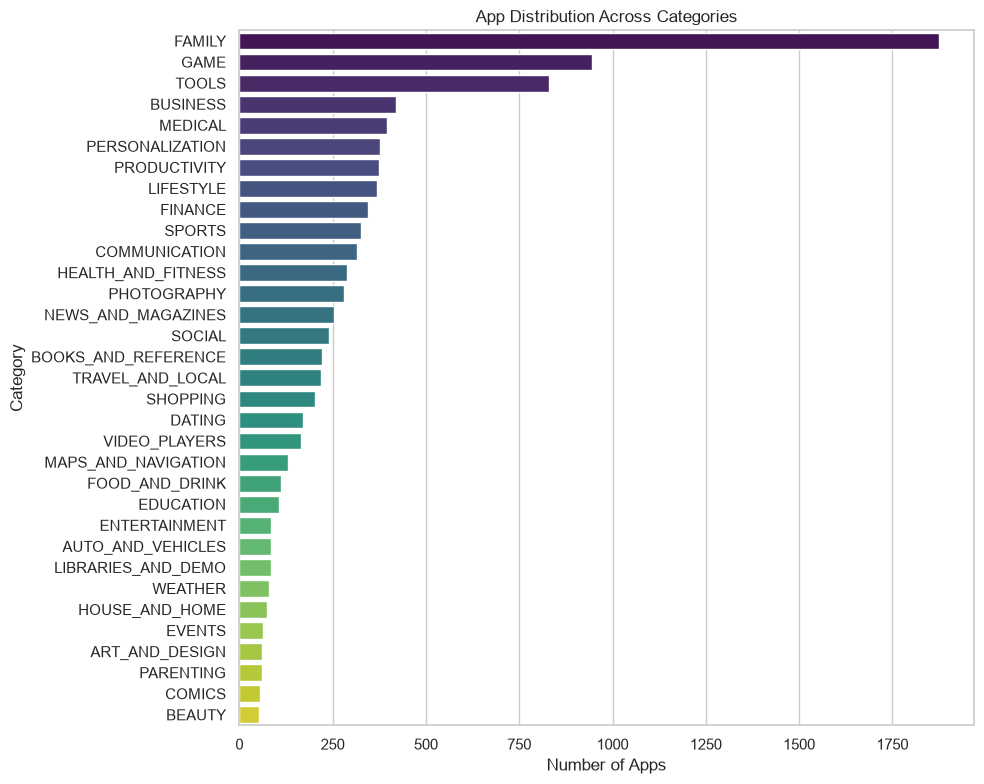

In [14]:
plt.figure(figsize=(10, 8))
category_counts = df_clean['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis', hue=category_counts.index, legend=False)
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.title('App Distribution Across Categories')
plt.tight_layout()
plt.show()

**Observation:** `FAMILY`, `GAME`, and `TOOLS` have by far the most apps — these categories are the most **saturated**, meaning a new app there faces the most competition. Categories near the bottom (e.g. `BEAUTY`, `COMICS`, `EVENTS`) have far fewer apps, which could mean less competition, but also less proven demand.

## 6. Ratings Analysis

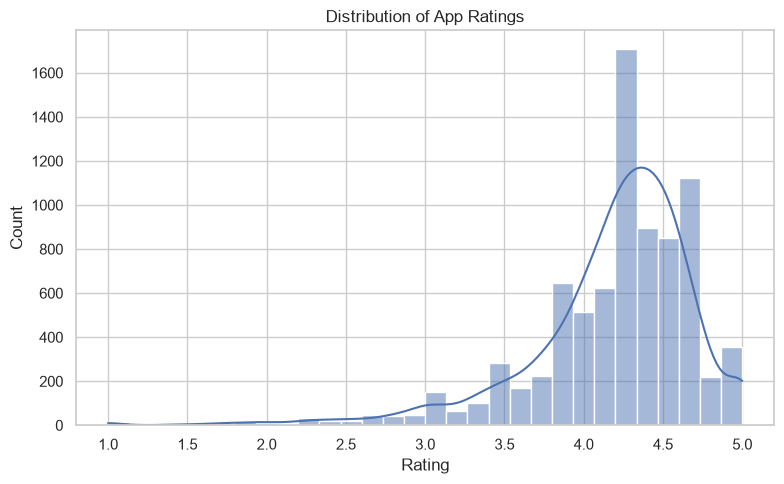

Median rating: 4.30


In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Rating'].dropna(), bins=30, kde=True, color='#4C72B0')
plt.xlabel('Rating')
plt.title('Distribution of App Ratings')
plt.tight_layout()
plt.show()

print(f"Median rating: {df_clean['Rating'].median():.2f}")

**Observation:** Ratings are heavily skewed toward the high end — most apps sit between 4.0 and 4.5 stars. Very few apps have a rating below 3.0.

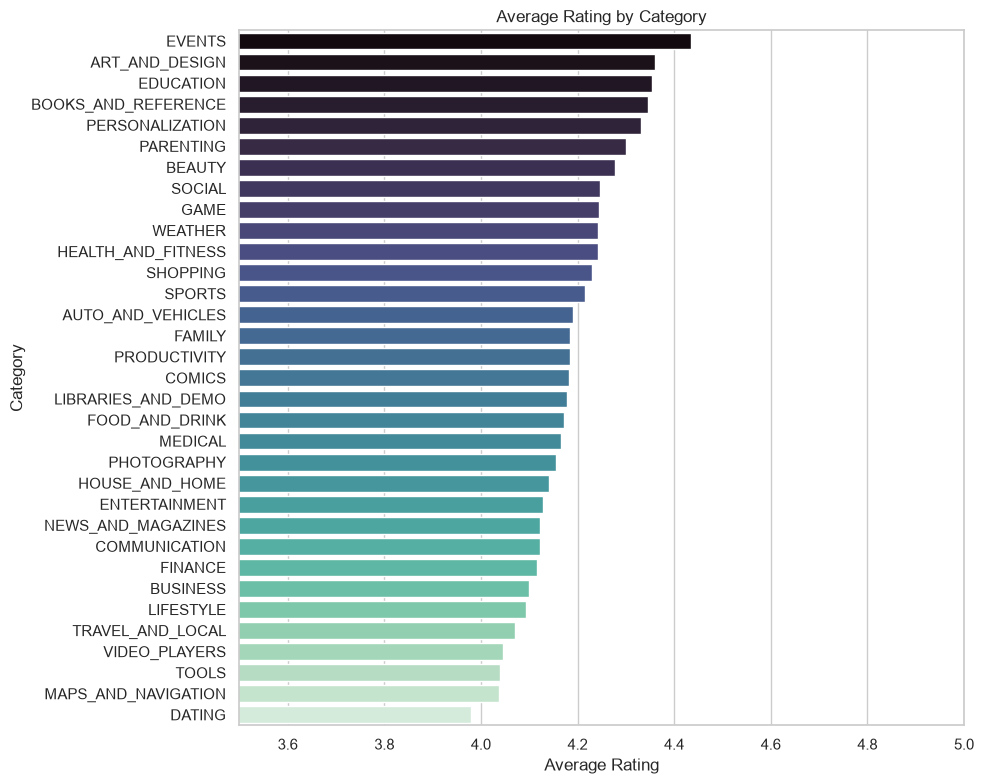

In [16]:
avg_rating_by_cat = df_clean.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako', hue=avg_rating_by_cat.index, legend=False)
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.title('Average Rating by Category')
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()

**Observation:** Average ratings are fairly close across categories (mostly 4.0–4.5) — no category stands out as clearly worse. `EVENTS`, `BOOKS_AND_REFERENCE`, and `ART_AND_DESIGN` tend to rate slightly higher on average.

## 7. Size vs. Installs

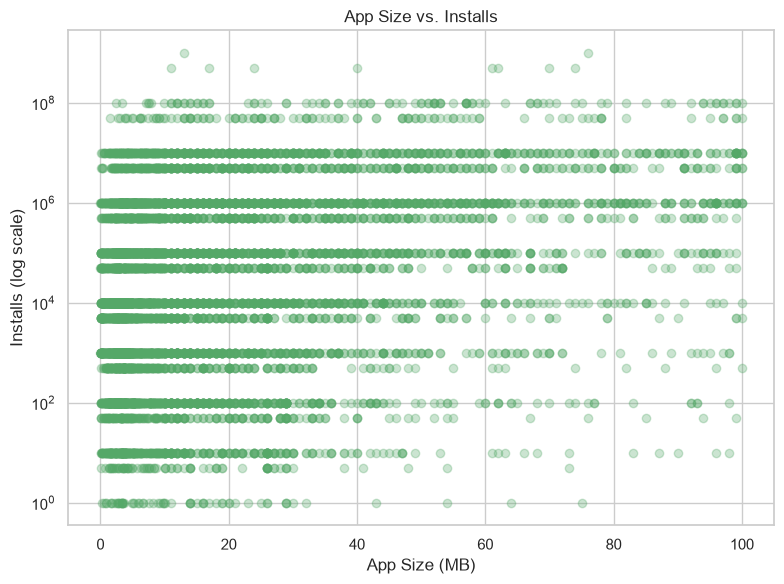

Correlation (Size vs Installs): 0.134


In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Size_MB'], df_clean['Installs'], alpha=0.3, color='#55A868')
plt.yscale('log')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Installs')
plt.tight_layout()
plt.show()

corr = df_clean[['Size_MB', 'Installs']].corr().iloc[0, 1]
print(f"Correlation (Size vs Installs): {corr:.3f}")

**Observation:** There's no strong relationship between app size and install count (correlation is close to zero). Small and large apps both range from very few to billions of installs — size alone doesn't predict popularity.

## 8. Pricing Analysis

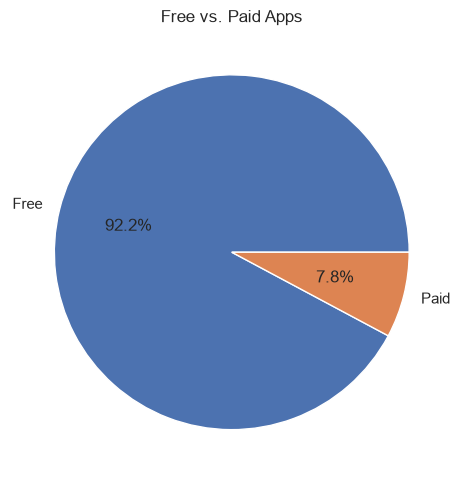

Type
Free    8905
Paid     754
Name: count, dtype: int64

In [18]:
type_counts = df_clean['Type'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
plt.title('Free vs. Paid Apps')
plt.tight_layout()
plt.show()

type_counts

**Observation:** The vast majority of apps (over 90%) are free. Paid apps are a small niche.

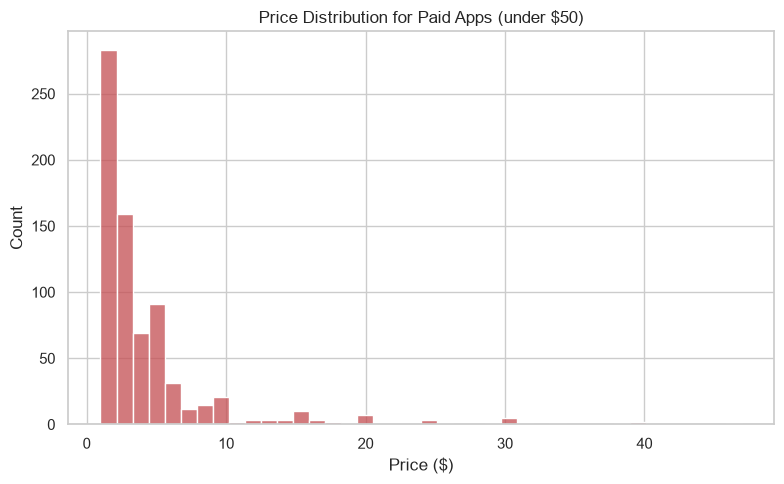

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


In [19]:
paid_df = df_clean[df_clean['Type'] == 'Paid']

plt.figure(figsize=(8, 5))
sns.histplot(paid_df[paid_df['Price'] < 50]['Price'], bins=40, color='#C44E52')
plt.xlabel('Price ($)')
plt.title('Price Distribution for Paid Apps (under $50)')
plt.tight_layout()
plt.show()

print(paid_df['Price'].describe())

**Observation:** Most paid apps are cheap — typically under $5. A handful of expensive outlier apps (well over $50) pull the average price up far above the typical price.

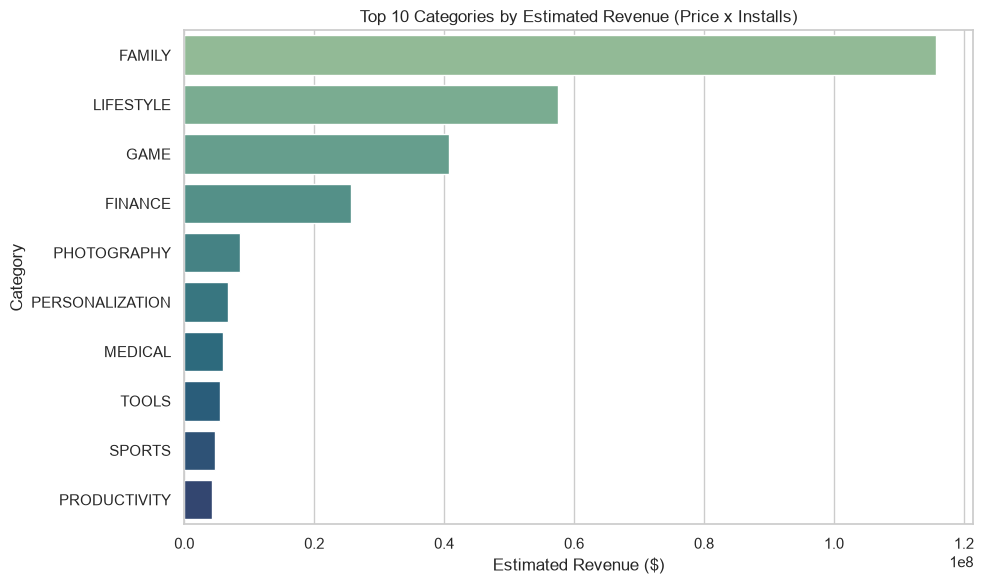

In [20]:
# Rough revenue estimate: Price x Installs (assumes every install was a full-price paid download —
# a simplifying assumption, not an exact revenue figure, but useful for relative comparison across categories)
df_clean['Est_Revenue'] = df_clean['Price'] * df_clean['Installs']

revenue_by_category = df_clean.groupby('Category')['Est_Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='crest', hue=revenue_by_category.index, legend=False)
plt.xlabel('Estimated Revenue ($)')
plt.ylabel('Category')
plt.title('Top 10 Categories by Estimated Revenue (Price x Installs)')
plt.tight_layout()
plt.show()

**Observation:** `FAMILY`, `GAME`, and `PHOTOGRAPHY` lead in estimated revenue — this is a rough proxy (price × installs), not real revenue, since it assumes every install was a full-price purchase, but it's useful for comparing categories relative to each other.

## 9. Sentiment Analysis on User Reviews

No real user-reviews file was available for this project, so we **simulate** a review dataset here to demonstrate the full sentiment analysis workflow. Reviews are generated from positive / negative / neutral templates, weighted by each app's actual rating (higher-rated apps get more positive reviews) so the simulated sentiment loosely tracks real rating patterns.

**To use real data instead:** replace this generation step with `pd.read_csv('googleplaystore_user_reviews.csv')` (the matching Kaggle reviews file), which has an `App` and `Translated_Review` column.


In [21]:
positive_templates = [
    "Love this app, works perfectly!",
    "Amazing experience, highly recommend it.",
    "This app is fantastic and so easy to use.",
    "Best app in its category, great job developers.",
    "Great interface and super smooth performance.",
    "Exactly what I needed, five stars!",
    "Very useful and reliable, use it daily.",
    "Superb app, no issues at all.",
    "I really enjoy using this app every day.",
    "Fantastic app, exceeded my expectations.",
]
negative_templates = [
    "Terrible app, crashes constantly.",
    "Waste of time, does not work as advertised.",
    "Full of bugs and ads, very frustrating.",
    "Worst app I have ever used.",
    "Keeps freezing, needs serious fixes.",
    "Not worth the download, deleted it immediately.",
    "Too many ads ruin the experience.",
    "App stopped working after the last update.",
    "Poor support and buggy features.",
    "Disappointed, expected much better than this.",
]
neutral_templates = [
    "It's okay, does the job.",
    "Average app, nothing special about it.",
    "Works fine but could use more features.",
    "Decent app for basic use.",
    "Does what it says, no more no less.",
    "Simple app, gets the job done.",
    "Not bad, not great either.",
    "Fine for occasional use.",
    "Meets basic expectations, nothing more.",
    "An okay experience overall.",
]

def sentiment_weights(rating):
    if pd.isna(rating):
        return [0.34, 0.33, 0.33]
    if rating >= 4.3:
        return [0.75, 0.05, 0.20]
    if rating >= 3.5:
        return [0.45, 0.20, 0.35]
    return [0.15, 0.55, 0.30]

# sample up to 15 of the most-installed apps per category to keep this demo fast
sample_apps = (
    df_clean.sort_values('Installs', ascending=False)
    .groupby('Category')
    .head(15)[['App', 'Category', 'Rating']]
    .drop_duplicates(subset='App')
    .reset_index(drop=True)
)

rows = []
for _, r in sample_apps.iterrows():
    n_reviews = np.random.randint(5, 16)
    weights = sentiment_weights(r['Rating'])
    choices = np.random.choice(['pos', 'neg', 'neu'], size=n_reviews, p=weights)
    for c in choices:
        text = np.random.choice(
            positive_templates if c == 'pos' else negative_templates if c == 'neg' else neutral_templates
        )
        rows.append({'App': r['App'], 'Category': r['Category'], 'Review': text})

reviews_df = pd.DataFrame(rows)
print("Simulated reviews:", reviews_df.shape)
reviews_df.head()

Simulated reviews: (4905, 3)


,App,Category,Review
0,Facebook,SOCIAL,Fine for occasional use.
1,Facebook,SOCIAL,"Exactly what I needed, five stars!"
2,Facebook,SOCIAL,"Average app, nothing special about it."
3,Facebook,SOCIAL,"Keeps freezing, needs serious fixes."
4,Facebook,SOCIAL,"Love this app, works perfectly!"


In [22]:
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    if score <= -0.05:
        return 'Negative'
    return 'Neutral'

reviews_df['Sentiment'] = reviews_df['Review'].apply(classify_sentiment)
reviews_df['Sentiment'].value_counts()

Sentiment
Positive    3462
Neutral      843
Negative     600
Name: count, dtype: int64

**Observation:** VADER correctly sorts the simulated reviews into positive / negative / neutral buckets based on wording, matching the sentiment each template was written to express.

## 10. Sentiment by Category

<Figure size 1000x800 with 0 Axes>

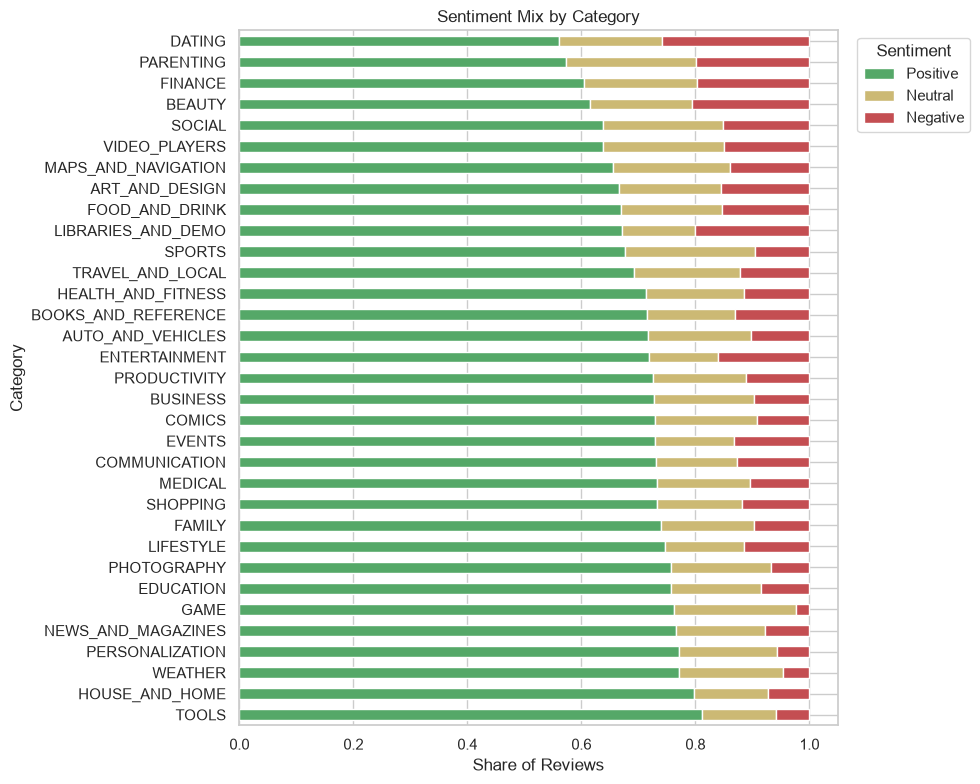

In [23]:
sentiment_by_cat = (
    reviews_df.groupby('Category')['Sentiment']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .sort_values('Positive', ascending=False)
)

plt.figure(figsize=(10, 8))
sentiment_by_cat[['Positive', 'Neutral', 'Negative']].plot(
    kind='barh', stacked=True, figsize=(10, 8), color=['#55A868', '#CCB974', '#C44E52']
)
plt.xlabel('Share of Reviews')
plt.title('Sentiment Mix by Category')
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** Categories built from higher-rated apps naturally show a larger share of positive sentiment here, since the simulation ties review tone to app rating — with real review data, this chart would reveal actual user pain points per category instead.

## 11. Interactive Visualization

In [25]:
top_categories = df_clean['Category'].value_counts().head(12).index
plot_df = df_clean[df_clean['Category'].isin(top_categories)].dropna(subset=['Size_MB', 'Rating']).copy()

fig = px.scatter(
    plot_df,
    x='Size_MB',
    y='Installs',
    color='Category',
    size='Rating',
    hover_data=['App', 'Price'],
    log_y=True,
    title='App Size vs. Installs by Category (bubble size = Rating)',
)
fig.update_layout(height=600)
fig.show()

## 12. Conclusion — Insights for a Developer Planning a New App

1. **Avoid launching into `FAMILY`, `GAME`, or `TOOLS` without a clear differentiator.** These categories are the most saturated (Section 5) — competition is steep, so a generic app is unlikely to stand out.

2. **App size doesn't drive installs — focus on quality and marketing instead.** There's essentially no correlation between size and popularity (Section 7), so investing engineering effort in shrinking the app is not, by itself, a growth lever.

3. **If charging for the app, price it low (under $5) and expect a small market.** Over 90% of apps are free, and paid apps cluster at low prices (Section 8) — a freemium or ad-supported model is the more common, lower-risk path to reach a large install base.
